**Train the Model for Spam / Ham Emails using Logistic Regression Algorithm**

**Description of Spam/Ham Datadet**

I download the Dataset from Kaggle.com
***About Dataset***
The Spam Assassin Dataset is a a selection of mail messages, suitable for use in testing spam filtering systems. This particular set was obtained from the Apache Public Datasets, cleaned and organized into a csv file

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/spam_assassin.csv")
df.head(10)

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0
5,From tobaccodemon@terra.es Sat Sep 7 22:05:58 ...,1
6,From larlar78@MailOps.Com Sat Jun 30 00:19:08 ...,1
7,From rpm-list-admin@freshrpms.net Thu Jul 25 1...,0
8,From exmh-users-admin@redhat.com Wed Aug 7 06:...,0
9,From contractor@goldenbay.com.cy Tue Jul 23 23...,1


In [ ]:
# rename the column of Spam & Ham
df.rename(columns={'label':'target'},inplace=True)
df.head(5)

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


In [ ]:
# convert spam ham into numbers
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head(5)

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


**1-Data Cleaning**

In [ ]:
# Checking - How many rows and columns?
print(df.shape)

(5796, 2)


In [ ]:
# Delete the rows which have any missing value
df.dropna(axis=0, inplace=True)

In [ ]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(467)

In [ ]:
# reomve the duplicate values
df = df.drop_duplicates(keep='first')

In [ ]:
# Again Check duplacate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Again Checking - How many rows and columns?
print(df.shape)

(5329, 2)


In [ ]:
# Print the first record of dataset for observation
print(df.iloc[0]['text'])

From ilug-admin@linux.ie Mon Jul 29 11:28:02 2002 Return-Path: <ilug-admin@linux.ie> Delivered-To: yyyy@localhost.netnoteinc.com Received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (Postfix) with ESMTP id A13D94414F for <jm@localhost>; Mon, 29 Jul 2002 06:25:11 -0400 (EDT) Received: from phobos [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single-drop); Mon, 29 Jul 2002 11:25:11 +0100 (IST) Received: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g6RHn7i17130 for <jm-ilug@jmason.org>; Sat, 27 Jul 2002 18:49:07 +0100 Received: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id SAA25016; Sat, 27 Jul 2002 18:45:03 +0100 X-Authentication-Warning: lugh.tuatha.org: Host root@localhost [127.0.0.1] claimed to be lugh Received: from mail1.mail.iol.ie (mail1.mail.iol.ie [194.125.2.192]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id SAA24977 fo

**2-Data Processing**

In [ ]:
!pip install nltk

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
stopwords.words('english')
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def text_processing_f(text):
    # 1-convert to lower case
    text = text.lower()

    # 2-Tokenize the words
    text = nltk.word_tokenize(text)

    # 3-remove special characters
    text = [word for word in text if word.isalnum()]


    #3-remove stopwords(eg a,is,the,for,on etc)
    # remove Punctuations(!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~)
    text = [word for word in text
            if word not in stopwords.words('english') and
            word not in string.punctuation]


    # 4-remove numbers, d+ >> matcehed each digit separately
    text = [word for word in text
            if word in re.sub(r'\d+' , '' , word)]

    # 5-remove the words which have less than 2 letters
    text = [word for word in text if len(word)>=2 ]

    # 6-Stemming (eg. Dance,Dancing,danced convert to dance)
    text = [ps.stem(word) for word in text]

    return " ".join(text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**Check text_processing_f  FUNCTION**

In [ ]:
text_processing_f('I love YT lectures on Machine Learning. How about you 3034852299')

'love yt lectur machin learn'

In [ ]:
df['processed_text'] = df['text'].apply(text_processing_f)

In [ ]:
df.head(5)

,text,target,processed_text
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,mon jul yyyi receiv localhost localhost postfi...
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,mon jun tue jun receiv esmtp id jm tue jun rec...
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1,mon jul yyyi receiv localhost localhost postfi...
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1,mon jun mon jun receiv esmtp id jm mon jun rec...
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0,mon aug yyyi receiv localhost localhost postfi...


**Generate the word cloud of Spam Messages & Not Spam Messages**

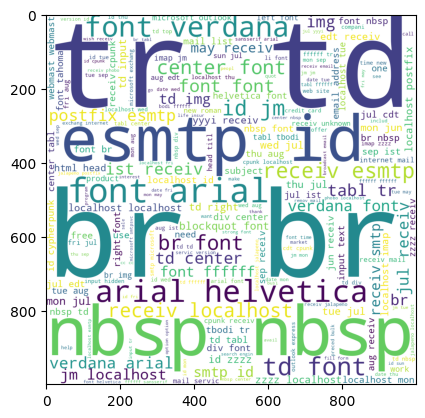

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
wc = WordCloud(
            width=1000,
            height=1000,
            min_font_size=12,
            background_color='white'
            )
spam_wc = wc.generate(df[df['target']==1]['processed_text'].str.cat(sep=' '))
plt.imshow(spam_wc)

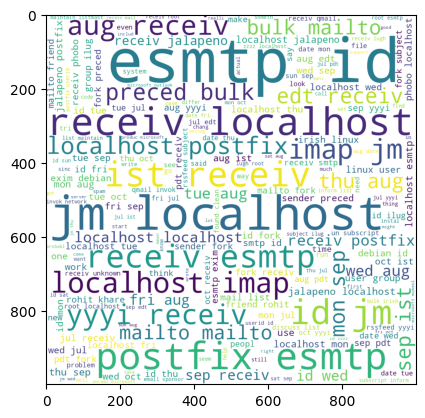

In [ ]:
not_spam_wc=wc.generate(df[df['target']==0]['processed_text'].str.cat(sep=' '))
plt.imshow(not_spam_wc)

**Find Top 30 common words of spam messages**

In [ ]:
spam_top_w = []
for msg in df[df['target']==1]['processed_text'].tolist():
    for word in msg.split():
        spam_top_w.append(word)
len(spam_top_w)

463789

In [ ]:
from collections import Counter
import seaborn as sns
df_spam_top_w = pd.DataFrame(Counter(spam_top_w).most_common(30))
print(df_spam_top_w)

            0      1
0        font  17545
1          br  16720
2        http   9581
3          td   9172
4      receiv   9115
5        nbsp   9080
6          id   5666
7          tr   5507
8       arial   5447
9   localhost   5053
10     center   4144
11        jul   4037
12      esmtp   3754
13  helvetica   3133
14         jm   2969
15    verdana   2905
16        img   2859
17      email   2787
18     ffffff   2650
19       tabl   2504
20        may   2375
21        mon   2370
22       free   2299
23        aug   2182
24    subject   2119
25      click   1910
26       mail   1909
27        tue   1833
28       date   1833
29        sep   1746


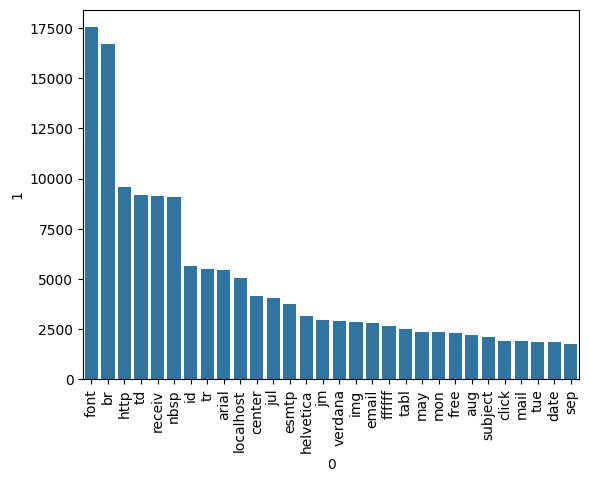

In [ ]:
sns.barplot(x=0,y=1,data=df_spam_top_w)
plt.xticks(rotation = 'vertical')
plt.show()

**Find Top 30 common words of ham messages**

In [ ]:
ham_top_w = []
for msg in df[df['target']==0]['processed_text'].tolist():
    for word in msg.split():
        ham_top_w.append(word)
len(ham_top_w)

657671

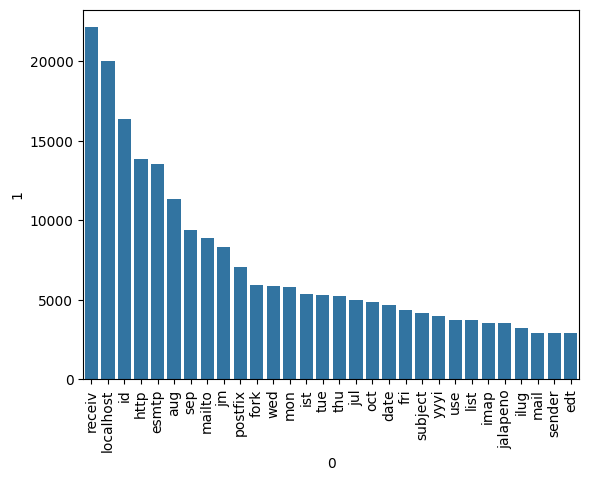

In [ ]:
df_ham_top_w = pd.DataFrame(Counter(ham_top_w).most_common(30))
sns.barplot(x=0,y=1,data=df_ham_top_w)
plt.xticks(rotation = 'vertical')
plt.show()

# **Build the Model**

In [ ]:
# vectorize the text column
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [ ]:
X = cv.fit_transform(df['processed_text']).toarray()
print(X)
print(X.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(5329, 27819)


In [ ]:
y = df['target'].values
print(y)
print(y.shape)

[0 1 1 ... 1 0 0]
(5329,)


**Split The Dataset by 80/20 rule**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

**Fit the Model**

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train, y_train)
y_predict_gnb = gnb.predict(X_test)
print("accuracy score   : " , accuracy_score(y_test, y_predict_gnb))
print("confusion matrix :\n " , confusion_matrix(y_test, y_predict_gnb))
print("Precision score  : " , precision_score(y_test, y_predict_gnb))

accuracy score   :  0.9699812382739212
confusion matrix :
  [[707   9]
 [ 23 327]]
Precision score  :  0.9732142857142857


In [ ]:
mnb.fit(X_train, y_train)
y_predict_mnb = mnb.predict(X_test)
print("accuracy score   : " , accuracy_score(y_test, y_predict_mnb))
print("confusion matrix :\n " , confusion_matrix(y_test, y_predict_mnb))
print("Precision score  : " , precision_score(y_test, y_predict_mnb))

accuracy score   :  0.9671669793621013
confusion matrix :
  [[714   2]
 [ 33 317]]
Precision score  :  0.9937304075235109


In [ ]:
bnb.fit(X_train, y_train)
y_predict_bnb = bnb.predict(X_test)
print("accuracy score   : " , accuracy_score(y_test, y_predict_bnb))
print("confusion matrix :\n " , confusion_matrix(y_test, y_predict_bnb))
print("Precision score  : " , precision_score(y_test, y_predict_bnb))

accuracy score   :  0.9652908067542214
confusion matrix :
  [[710   6]
 [ 31 319]]
Precision score  :  0.9815384615384616


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

In [ ]:
lr = LogisticRegression(solver='liblinear', penalty='l1')
svc = SVC(kernel = 'sigmoid', gamma=1.0)
linear_svc = LinearSVC(random_state=0, tol=1e-5)
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=2)
bgc  = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [ ]:
clfs = {
    'LogisticRegression'         : lr,
    'SVC'                        : svc,
    'LinearSVC'                  : linear_svc,
    'MultinomialNB'              : mnb,
    'DecisionTreeClassifier'     : dtc,
    'KNeighborsClassifier'       : knc,
    'RandomForestClassifier'     : rfc,
    'AdaBoostClassifier'         : abc,
    'GradientBoostingClassifier' : gbc,
    'BaggingClassifier'          : bgc,
    'ExtraTreesClassifier'       : etc,
    'XGBClassifier'              : xgb
}

In [ ]:
def train_classifier_f(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision


In [ ]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
        current_accuracy, current_precision = train_classifier_f(clf, X_train,y_train, X_test, y_test)

        print("For" , name)
        print("Accuracy" , current_accuracy)
        print("Precision" , current_precision)

        accuracy_scores.append(current_accuracy)
        precision_scores.append(current_precision)


For LogisticRegression
Accuracy 0.9924953095684803
Precision 0.9913793103448276
For SVC
Accuracy 0.6688555347091932
Precision 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


For LinearSVC
Accuracy 0.9943714821763602
Precision 0.9942528735632183
For MultinomialNB
Accuracy 0.9671669793621013
Precision 0.9937304075235109
For DecisionTreeClassifier
Accuracy 0.9634146341463414
Precision 0.9669669669669669
For KNeighborsClassifier
Accuracy 0.9681050656660413
Precision 0.9647058823529412
For RandomForestClassifier
Accuracy 0.9924953095684803
Precision 1.0
For AdaBoostClassifier
Accuracy 0.9831144465290806
Precision 0.9911242603550295
For GradientBoostingClassifier
Accuracy 0.9868667917448405
Precision 0.9912280701754386
For BaggingClassifier
Accuracy 0.9812382739212008
Precision 0.9714285714285714
For ExtraTreesClassifier
Accuracy 0.9915572232645403
Precision 0.9942028985507246
For XGBClassifier
Accuracy 0.9934333958724203
Precision 0.9942363112391931


In [ ]:
performan_df = pd.DataFrame({'Algorithm':clfs.keys(),
                             'Accuracy':accuracy_scores,
                             'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df = performan_df.set_index('Algorithm')
performance_df.head(10)

,Accuracy,Precision
Algorithm,,
RandomForestClassifier,0.992495,1.000000
LinearSVC,0.994371,0.994253
XGBClassifier,0.993433,0.994236
ExtraTreesClassifier,0.991557,0.994203
MultinomialNB,0.967167,0.993730
LogisticRegression,0.992495,0.991379
GradientBoostingClassifier,0.986867,0.991228
AdaBoostClassifier,0.983114,0.991124
BaggingClassifier,0.981238,0.971429


I Select the Model 'Random Forest'
because

*   text dataset more rely on precision is 100%
*   Accuracy is also nearest 100%




In [ ]:
# Save the model
import joblib
joblib.dump(rfc, open('/content/drive/MyDrive/model_spam_ham.joblib', 'wb'))
joblib.dump(cv, open('/content/drive/MyDrive/vectorizer.joblib', 'wb'))

#**Now make the UI**

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 30.4 MB/s eta 0:00:00


In [ ]:
import joblib
import streamlit as st
import streamlit as st
import string
from nltk.corpus import stopwords
import nltk
from nltk.stem import PorterStemmer
ps = PorterStemmer()
import re
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Load the model
model = joblib.load('/content/drive/MyDrive/model_spam_ham.joblib')
cv = joblib.load('/content/drive/MyDrive/vectorizer.joblib')
import os
print(os.path.exists('/content/drive/MyDrive/vectorizer.joblib'))
print(os.path.exists('/content/drive/MyDrive/model_spam_ham.joblib'))


True
True


In [ ]:
%%writefile app.py
# Create text Processing function for input
def text_processing_f(text):
    # 1-convert to lower case
    text = text.lower()

    # 2-Tokenize the words
    text = nltk.word_tokenize(text)

    # 3-remove special characters
    text = [word for word in text if word.isalnum()]


    #3-remove stopwords(eg a,is,the,for,on etc)
    # remove Punctuations(!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~)
    text = [word for word in text
            if word not in stopwords.words('english') and
            word not in string.punctuation]


    # 4-remove numbers, d+ >> matcehed each digit separately
    text = [word for word in text
            if word in re.sub(r'\d+' , '' , word)]

    # 5-remove the words which have less than 2 letters
    text = [word for word in text if len(word)>=2 ]

    # 6-Stemming (eg. Dance,Dancing,danced convert to dance)
    text = [ps.stem(word) for word in text]

    return " ".join(text)



# Create the UI
st.title("Spam Email Detector App")
input_email = st.text_input("Enter or Paste the text of Email")

# Preprocess the
processed_input_text = text_processing_f(input_email)
# Vectorize
vectorized_input_text = cv.transform([processed_input_text])
# Predict
final_result = model.predict(vectorized_input_text)[0]
# Display
if st.button("Predict"):
    if final_result == 1:
        st.header("This is a Spam Email")
    else:
        st.header("This is not a Spam Email")


Writing app.py


In [ ]:
!ls

app.py	drive  sample_data


In [ ]:
!ls -l app.py

-rw-r--r-- 1 root root 1405 Jul 19 20:09 app.py


In [ ]:
!streamlit run app.py



2026-07-19 20:10:21.459 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.181.160.67:8501



In [ ]:
!streamlit --version

Streamlit, version 1.59.2
